# 实验介绍

实验改编自《深度学习框架PyTorch：入门与实践（陈云）》中《AI 诗人：用 RNN写诗》。参考：https://github.com/chenyuntc/pytorch-book.git  

本实验基于改编后的charRNN进行训练，生成古诗。古诗生成有两种方式：生成藏头诗和续写古诗。

**实验任务**

1. 完成环境配置和pytorch使用，对原始数据进行预处理，生成numpy的压缩包tang.npz（30%）  
2. 从底层构建LSTM，自行调节相关参数进行训练，窗口保留打印的训练日志，并生成loss.png（完整构建多层LSTM占40%，只构建单层LSTM占30%）  
3. 基于训练后的模型，测试生成藏头诗和续写诗歌（每个占10%， 共占20%）
4. 调用大语言模型生成古诗生成和测试困惑度（10%） 

# 环境配置和pytorch使用

环境配置

创建conda虚拟环境 

```python
conda create -n poetry python=3.9 -y
conda activate poetry
```

安装pytorch：在 [pytorch官网](https://pytorch.org/) install部分，根据你的硬件条件选择对应的安装命令。例如：
```python
pip3 install torch torchvision torchaudio
```

安装numpy, pandas, matplotlib, tqdm, opencc-python-reimplemented

In [ ]:
%pip install numpy pandas matplotlib tqdm opencc-python-reimplemented

导入库

In [4]:
import os
import re
import json
import math
from tqdm import tqdm
import numpy as np
from opencc import OpenCC

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import random_split, DataLoader
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt


In [5]:
print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0+cu124


**pytorch使用**

1. 张量（tensor）   
张量是pytorch最基本的数据结构，类似于numpy.ndarray，可以挂载到GPU上加速计算。

In [6]:
# 创建一个2×2的张量x
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print(x)

# 创建一个形状为(2,3)的张量rand_x并随机初始化
rand_x = torch.randn(2, 3)
print(rand_x)

# 张量运算
y = x + 2
z = x * y  # 逐元素相乘
print(z)

# 检测GPU并将张量z移动到设备上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z = z.to(device)
print(z)


tensor([[1., 2.],
        [3., 4.]])
tensor([[ 1.1404, -1.0605, -0.7833],
        [-0.7117,  0.7983, -0.5666]])
tensor([[ 3.,  8.],
        [15., 24.]])
tensor([[ 3.,  8.],
        [15., 24.]], device='cuda:0')


2. 自动求导（Autograd）  
pytorch具有自动求导功能，支持反向传播。   

In [8]:
x = torch.randn(3, requires_grad=True)  # requires_grad表示是否需要计算梯度
print(x)
y = x * 2
z = y.mean()  # 计算均值

# TODO: 在此添加反向传播代码，计算梯度
z.backward()

# TODO：输出x的梯度
print(x.grad)


tensor([ 2.4394,  0.4265, -1.1710], requires_grad=True)
tensor([0.6667, 0.6667, 0.6667])


3. 神经网络模块（nn.Module）  
pytorch提供了一个`nn.Module`类，用于构建神经网络。通过继承这个类，我们可以定义自己的网络结构。

In [9]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # 输入层到隐藏层
        self.fc2 = nn.Linear(5, 2)   # 隐藏层到输出层

    def forward(self, x):
        # TODO: 补全前向传播过程
        # 通过fc1后，使用ReLU激活函数，然后通过fc2
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = SimpleNet()
print(net)

SimpleNet(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=2, bias=True)
)


4. 训练：损失函数，优化器，前向传播+反向传播

In [10]:
# TODO：选择损失函数
# 分类任务常用CrossEntropyLoss，回归任务常用MSELoss
criterion = nn.MSELoss()

# TODO: 选择优化器
# 简单小规模任务SGD随机梯度下降
optimizer = optim.SGD(net.parameters(), lr=0.01)

In [11]:
# 创建输入和目标张量
inputs = torch.randn(4, 10)
targets = torch.randn(4, 2)

# 前向传播
outputs = net(inputs)
print("Outputs:", outputs)

# TODO：计算损失
loss = criterion(outputs, targets)
print("Loss:", loss.item())

# 后向传播
# TODO: 清除之前的梯度；计算梯度；更新参数
optimizer.zero_grad()
loss.backward()
optimizer.step()


print("Updated network parameters:")
for name, param in net.named_parameters():
    print(name, param.detach())

Outputs: tensor([[-0.7315, -0.1136],
        [-0.4244, -0.2814],
        [-0.6018, -0.1767],
        [-0.4378, -0.2713]], grad_fn=<AddmmBackward0>)
Loss: 1.1822739839553833
Updated network parameters:
fc1.weight tensor([[-0.0343,  0.1477,  0.2980,  0.1589, -0.2626,  0.0077, -0.0085, -0.2872,
         -0.1060, -0.0604],
        [ 0.1799, -0.2884,  0.1701,  0.0586, -0.0691, -0.2998,  0.1872,  0.2033,
         -0.1027, -0.0717],
        [ 0.0101,  0.2159,  0.2168,  0.2324, -0.1489,  0.1187, -0.0612,  0.0197,
          0.3009,  0.1236],
        [ 0.2115,  0.0980, -0.1483, -0.0309,  0.0188,  0.0281, -0.1841,  0.1137,
         -0.3007, -0.2328],
        [ 0.2029, -0.0813, -0.2864,  0.0552,  0.2869,  0.2179, -0.1365, -0.0824,
         -0.2213,  0.2823]])
fc1.bias tensor([-0.1593,  0.2263, -0.0909,  0.0399, -0.1499])
fc2.weight tensor([[-0.0925, -0.4336, -0.3869, -0.0907, -0.0270],
        [ 0.0350,  0.1745, -0.0246,  0.1161, -0.2666]])
fc2.bias tensor([-0.4182, -0.2564])


In [12]:
import torch
import torch.nn as nn
import numpy as np

# 创建数据
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])

# 定义模型
model = nn.Linear(1, 1)  # 输入特征数量为1，输出特征数量也为1

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器

# 训练模型
for epoch in range(100):  # 迭代100次
    # 前向传播
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    
    # 反向传播和优化
    optimizer.zero_grad()  # 清除之前的梯度
    loss.backward()  # 反向传播计算梯度
    optimizer.step()  # 根据梯度更新参数
    
    print(f'Epoch [{epoch+1}/100], Loss: {loss.item()}')

print("Updated network parameters:")
for name, param in model.named_parameters():
    print(name, param.detach())

Epoch [1/100], Loss: 25.09096336364746
Epoch [2/100], Loss: 19.83414649963379
Epoch [3/100], Loss: 15.678912162780762
Epoch [4/100], Loss: 12.39441204071045
Epoch [5/100], Loss: 9.798188209533691
Epoch [6/100], Loss: 7.746006011962891
Epoch [7/100], Loss: 6.123861789703369
Epoch [8/100], Loss: 4.841638088226318
Epoch [9/100], Loss: 3.8281033039093018
Epoch [10/100], Loss: 3.0269529819488525
Epoch [11/100], Loss: 2.393681764602661
Epoch [12/100], Loss: 1.8931102752685547
Epoch [13/100], Loss: 1.4974302053451538
Epoch [14/100], Loss: 1.184660792350769
Epoch [15/100], Loss: 0.9374286532402039
Epoch [16/100], Loss: 0.7420002818107605
Epoch [17/100], Loss: 0.5875189900398254
Epoch [18/100], Loss: 0.46540531516075134
Epoch [19/100], Loss: 0.3688763678073883
Epoch [20/100], Loss: 0.29257044196128845
Epoch [21/100], Loss: 0.23224979639053345
Epoch [22/100], Loss: 0.18456514179706573
Epoch [23/100], Loss: 0.14686790108680725
Epoch [24/100], Loss: 0.11706585437059402
Epoch [25/100], Loss: 0.0935

# 步骤一：数据预处理

**数据集**

数据是来自 GitHub上中文诗词爱好者收集的5万多首唐诗原文，选择“全唐诗”，链接：https://github.com/chinese-poetry/chinese-poetry.git

## 数据清洗

**STEP 1：读取数据**

将数据集放到`data_path`下，函数`_parseRawData`读取`poet.tang`为前缀的`JSON`文件列表，之后遍历每个文件，调用 `_handle_json` 遍历该文件中的每首诗歌，将符合条件的诗歌进行清洗，最后拼接成list。你可以通过指定 `author` 和 `constrain` 参数来过滤数据。

In [13]:
def _parseRawData(data_path, category, author=None, constrain=None):

    def _handle_json(file):
        """读入 json 文件，返回诗句 list，每个元素是一首诗（str 类型）"""
        rst = []
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
        for poetry in data:
            if author and poetry.get("author") != author:
                continue
            p = poetry.get("paragraphs", [])
            if not p:
                continue
            pdata = []
            flag = False
            for s in p:
                sp = re.split(r"[，！。]", s)
                for tr in sp:
                    if constrain and 0 < len(tr) != constrain:  
                        flag = True
                        break
                if flag:
                    break
            if flag:
                continue
            pdata.extend(poetry.get("paragraphs"))
            pdata = _sentence_parse("".join(pdata))
            if pdata and len(pdata) > 1:
                rst.append(pdata)
        return rst

    data = []    
    file_list = [f for f in os.listdir(data_path) if f.startswith(category)]
    for filename in tqdm(file_list, desc="Parsing JSON Files"):
        data.extend(_handle_json(os.path.join(data_path, filename)))
    
    return data

In [14]:
data_path = './data'  #'your data path'
category = "poet.tang"  # 类别，唐诗还宋诗歌(poet.song)
author = None # 只学习某位作者的诗歌
constrain = None # 长度限制

**STEP 2：数据清洗**

`_sentence_parse`负责对数据进行清洗。

一方面，数据集中会存在一些不规范的文本，包括多余的括号、数字、连字符等，例如在 `poet.tang.50000.json` 文件中就存在一些脏数据。  
另一方面原始数据是繁体中文的， 虽然诗歌更有韵味，但是对于习惯了简体中文的读者来说可能还是有点别扭，所以我们在这一步借助`opencc`库将繁体字转为简体字。

In [15]:
def _sentence_parse(para):
    """对文本进行处理，取出脏数据并转换为简体"""
    # 去掉括号中的部分
    result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)

    # 去掉数字和 '-'
    result = "".join(s for s in result if not s.isdigit() and s != '-')
 
    # 处理两个句号变为一个句号
    result = re.sub("。。", "。", result)
    
    # 繁体转简体
    cc = OpenCC('t2s')  # 't2s' 表示从繁体转换为简体
    result = cc.convert(result)
    
    return result

In [16]:
# 1. 获取数据
data = _parseRawData(data_path, category, author, constrain)

Parsing JSON Files: 100%|██████████| 58/58 [01:48<00:00,  1.86s/it]


**STEP 3：构建词典（TODO）**

构建词汇表`word2ix`和`ix2word`，分别是字符到索引和索引到字符的映射字典。你需要向词汇表`word2ix`，包括`<START>`、`<EOP>`、`<UNK>`、`</s>`。

In [17]:
# 3. 构建词典
chars = sorted({c for line in data for c in line})
word2ix = {char: ix for ix, char in enumerate(chars)}

word2ix['<EOP>'] = len(word2ix)
# TODO：添加<START>、<UNK>、</s>
for token in ['<START>', '<EOP>', '<UNK>', '</s>']:
    if token not in word2ix:
        word2ix[token] = len(word2ix)

ix2word = {ix: char for char, ix in word2ix.items()}

**STEP 4：数据格式化和序列填充（TODO）**

In [18]:
def pad_sequences(sequences,
                  maxlen=None,
                  dtype='int32',
                  padding='pre',
                  truncating='pre',
                  value=0.):
    """
    code from keras
    Pads each sequence to the same length (length of the longest sequence).
    If maxlen is provided, any sequence longer
    than maxlen is truncated to maxlen.
    Truncation happens off either the beginning (default) or
    the end of the sequence.
    Supports post-padding and pre-padding (default).
    Arguments:
        sequences: list of lists where each element is a sequence
        maxlen: int, maximum length
        dtype: type to cast the resulting sequence.
        padding: 'pre' or 'post', pad either before or after each sequence.
        truncating: 'pre' or 'post', remove values from sequences larger than
            maxlen either in the beginning or in the end of the sequence
        value: float, value to pad the sequences to the desired value.
    Returns:
        x: numpy array with dimensions (number_of_sequences, maxlen)
    Raises:
        ValueError: in case of invalid values for `truncating` or `padding`,
            or in case of invalid shape for a `sequences` entry.
    """
    if not hasattr(sequences, '__len__'):
        raise ValueError('`sequences` must be iterable.')
    lengths = []
    for x in sequences:
        if not hasattr(x, '__len__'):
            raise ValueError('`sequences` must be a list of iterables. '
                             'Found non-iterable: ' + str(x))
        lengths.append(len(x))

    num_samples = len(sequences)
    if maxlen is None:
        maxlen = np.max(lengths)

    # take the sample shape from the first non empty sequence
    # checking for consistency in the main loop below.
    sample_shape = tuple()
    for s in sequences:
        if len(s) > 0:  # pylint: disable=g-explicit-length-test
            sample_shape = np.asarray(s).shape[1:]
            break

    x = (np.ones((num_samples, maxlen) + sample_shape) * value).astype(dtype)
    for idx, s in enumerate(sequences):
        if not len(s):  # pylint: disable=g-explicit-length-test
            continue  # empty list/array was found
        if truncating == 'pre':
            trunc = s[-maxlen:]  # pylint: disable=invalid-unary-operand-type
        elif truncating == 'post':
            trunc = s[:maxlen]
        else:
            raise ValueError('Truncating type "%s" not understood' % truncating)

        # check `trunc` has expected shape
        trunc = np.asarray(trunc, dtype=dtype)
        if trunc.shape[1:] != sample_shape:
            raise ValueError(
                'Shape of sample %s of sequence at position %s is different from '
                'expected shape %s'
                % (trunc.shape[1:], idx, sample_shape))

        if padding == 'post':
            x[idx, :len(trunc)] = trunc
        elif padding == 'pre':
            x[idx, -len(trunc):] = trunc
        else:
            raise ValueError('Padding type "%s" not understood' % padding)
    return x

在每首诗的开头添加`<START>`标记，在结尾添加`<EOP>`标记。将文本数据转换为索引序列，以便于模型处理。使用`pad_sequences`函数将所有序列填充到指定长度，不足的部分进行填充。`pad_sequences`函数已给出，你需要完成函数调用。

In [19]:
# 4. 处理样本
# 4.1 每首诗加上首位符号
print("Adding start and end tokens...")
for i in tqdm(range(len(data)), desc="Processing poems"):
    data[i] = ['<START>'] + list(data[i]) + ['<EOP>']

# 4.2 文字转 ID
print("Converting words to indices...")
unk_id = word2ix['<UNK>']
data_id = [[word2ix.get(w, unk_id) for w in line] for line in tqdm(data, desc="Converting")]

# 4.3 补全既定长度(TODO)
print("Padding sequences...")
maxlen = 125 # 超过这个长度之后的字被丢弃，小于这个长度的在前面补空格
pad_data = pad_sequences(
    data_id,
    maxlen=maxlen,
    padding='pre',
    truncating='post',
    value=word2ix['</s>']
)
print(pad_data.shape)

Adding start and end tokens...


Processing poems: 100%|██████████| 57410/57410 [00:00<00:00, 371927.81it/s]


Converting words to indices...


Converting: 100%|██████████| 57410/57410 [00:00<00:00, 156165.18it/s]


Padding sequences...
(57410, 125)


**STEP 5：数据保存**

将数据保存为一个`numpy`的压缩包`tang.npz`，其中包含三个对象：data(numpy数组)，word2ix(类型为dict)，ix2word(类型为dict)。

详细介绍参考书籍章节《AI 诗人：用 RNN写诗》，需要注意的一点是由于仓库更新书中提供的压缩包和我们本次实验生成的压缩包不完全一致。

In [20]:
# 3.4 保存
pickle_path = os.path.join(data_path, "tang.npz")
np.savez_compressed(pickle_path, data=pad_data, word2ix=word2ix, ix2word=ix2word)
print(f"预处理数据保存在 {pickle_path}")

预处理数据保存在 ./data\tang.npz


## 数据描述

"data.npz"包含三个对象：  
- data:（57410, 125）的 numpy 数组，总共有 57580 首诗歌， 每首诗歌长度为 125 字符（不足 125 补空格，超过 125 的丢弃）。  
- word2ix ： 每个词和它对应的序号 
- ix2word ： 每个序号和它对应的词

In [21]:
def get_data(path):
    if not os.path.exists(path):
        print(f"Error: File {path} not found.")
        return None

    datas = np.load(path, allow_pickle=True)  # 加载数据
    data = datas.get('data')  # numpy.ndarray
    word2ix = datas['word2ix'].item() if 'word2ix' in datas else None  # dict
    ix2word = datas['ix2word'].item() if 'ix2word' in datas else None  # dict

    return data, word2ix, ix2word

In [22]:
# 加载数据
pickle_path = os.path.join('./data', "tang.npz")
data, word2ix, ix2word = get_data(pickle_path)
print(np.shape(data))  # (57410, 125)
print(data)
print(len(ix2word),len(word2ix)) # 8940

(57410, 125)
[[8939 8939 8939 ... 4515    6 8936]
 [8939 8939 8939 ...  651    6 8936]
 [8939 8939 8939 ...  537    6 8936]
 ...
 [8939 8939 8939 ... 6443    6 8936]
 [8939 8939 8939 ... 7143    6 8936]
 [8939 8939 8939 ... 4277    6 8936]]
8940 8940


In [23]:
# 查看第一首诗歌
poem = data[0]
print(poem)

#词序号转成对应的汉字
poem_txt = [ix2word[ii]for ii in poem]
print(''.join (poem_txt))

[8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939
 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939
 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939
 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939
 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939 8939
 8939 8939 8939 8939 8939 8937 4957 1935 7699 1975 1682 8399  717 6785
 1445 4606 1784    6 5419 3491  866 1746 6905 8399 4938 1707 4601 7703
  439    6 7148 4455 7224 2638 3547 8399 7910 6582 7152  696 6253    6
  325 2870 7675 1782 7612 8399 7897 4064  715 5419 4515    6 8936]
</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s><START>秦川雄帝宅，函谷壮皇居。绮殿千寻起，离宫百雉余。连甍遥接汉，飞观迥凌虚。云日隐层阙，风烟出绮疎。<EOP>


In [24]:
# 汉字转成对应的词序号
poem_txt = '度门能不访，冒雪屡西东。'
poem = [word2ix[i] for i in poem_txt]
print(poem)

[2038, 7565, 5700, 256, 6678, 8399, 666, 7717, 1797, 6569, 268, 6]


# 步骤二：构建模型并训练

请学习文档：[LSTM — PyTorch 2.6 documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)，搭建`LSTM`补全`model.py`文件，注意`layer_num`参数表示lstm的层数。

>参考学习的视频：【30、PyTorch LSTM和LSTMP的原理及其手写复现】 https://www.bilibili.com/video/BV1zq4y1m7aH/?share_source=copy_web&vd_source=8fc7ac1f0bd348ea72f5b97b6ad07afd

$$
\begin{align*}
i_t &= \sigma(W_{ii}x_t + b_{ii} + W_{hi}h_{t-1} + b_{hi}) \\
f_t &= \sigma(W_{if}x_t + b_{if} + W_{hf}h_{t-1} + b_{hf}) \\
g_t &= \tanh(W_{ig}x_t + b_{ig} + W_{hg}h_{t-1} + b_{hg}) \\
o_t &= \sigma(W_{io}x_t + b_{io} + W_{ho}h_{t-1} + b_{ho}) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{align*}
$$

如上图所示，你可以直接按照公式计算，例如表示出W<sub>ii</sub> , x<sub>t</sub> ,b<sub>ii</sub> ,W<sub>hi</sub> , h<sub>t-1</sub> , h<sub>hi</sub> 再带入公式来计算 i<sub>t</sub> ，之后每个门都如此。

也可以直接声明共享权重矩阵，例如，W_x = [W<sub>ii</sub>, W<sub>if</sub>, W<sub>ig</sub>, W<sub>io</sub> ]，先计算W_x * x<sub>t</sub>，之后再切片或者使用`chun`得到每个门的运算量。

```python
gates = x_t @ self.W_x + h_t @ self.W_h + self.bias
i_t, f_t, g_t, o_t = gates.chunk(4, dim=-1)
```

所以只要弄清楚权重的初始值，那么各个门的输入输出量就非常清晰了。

>【问题一】需要初始哪些权重，如何初始化？  
【Your answer】：
需要初始化 LSTM 中输入到四个门的权重、上一时刻隐藏状态到四个门的权重，以及对应偏置。若用合并矩阵实现，就是 `linear_x: input_size -> 4 * hidden_size` 和 `linear_h: hidden_size -> 4 * hidden_size` 的权重与偏置。输入侧权重可用 Xavier 均匀初始化，使不同输入维度的方差较稳定；循环侧权重可用正交初始化，有助于缓解长序列反向传播中的梯度消失或爆炸；偏置一般初始化为 0，其中遗忘门偏置可初始化为 1，让模型在训练初期更倾向于保留已有记忆。

书上给的示例代码是构建了两层LSTM（`num_layers=2`），所以你实际需要完成的是多层LSTM。

>【问题二】对于多层LSTM的构建，你需要清楚自己是要先遍历`num_layers`后遍历`seq_len`，还是先遍历`seq_len`后遍历`num_layers`  
【Your answer】：
应先遍历 `seq_len`，再在每个时间步内从第 1 层到第 `num_layers` 层依次遍历。这样第 `t` 个时间步中，第 `l` 层的输入就是同一时间步第 `l-1` 层的输出；同时每一层都会维护自己上一时间步的 `(h, c)` 状态。该顺序与标准堆叠 LSTM 的计算图一致，也便于返回形状为 `(seq_len, batch, hidden_dim)` 的顶层输出和形状为 `(num_layers, batch, hidden_dim)` 的最终隐状态。

In [25]:
class PoetryModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, layer_num):
        super(PoetryModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # TODO：创建多层LSTM
        self.lstm = MultiLayerLSTM(embedding_dim, hidden_dim, layer_num)

        self.linear1 = nn.Linear(self.hidden_dim, vocab_size)

    def forward(self, input, hidden=None):
        seq_len, batch_size = input.size()
 
        embeds = self.embeddings(input) # (seq_len, batch_size) -> (seq_len, batch_size, embedding_dim)

        output, hidden = self.lstm(embeds, hidden) # output size: (seq_len, batch_size, hidden_dim)

        output = self.linear1(output.view(seq_len*batch_size, -1)) # size: (seq_len*batch_size, vocab_size)

        return output, hidden

In [26]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # TODO：定义LSTM四个门的权重，也可以声明共享权重矩阵
        self.linear_x = nn.Linear(input_size, 4 * hidden_size)
        self.linear_h = nn.Linear(hidden_size, 4 * hidden_size)
        
        self.init_weights()

    # TODO：实现init_weights函数，初始化权重参数
    def init_weights(self):
        nn.init.xavier_uniform_(self.linear_x.weight)
        nn.init.orthogonal_(self.linear_h.weight)
        nn.init.zeros_(self.linear_x.bias)
        nn.init.zeros_(self.linear_h.bias)
        # 遗忘门偏置设为1，帮助模型在训练初期保留历史信息
        with torch.no_grad():
            self.linear_x.bias[self.hidden_size:2 * self.hidden_size].fill_(1.0)

    # TODO: 实现forward函数
    def forward(self, x, state):
        h_prev, c_prev = state
        gates = self.linear_x(x) + self.linear_h(h_prev)
        i, f, g, o = gates.chunk(4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c
 

class MultiLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(MultiLayerLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO: 叠加多个LSTMCell
        # 可以使用nn.ModuleList()存储多个LSTMCell层
        self.layers = nn.ModuleList([
            LSTMCell(input_size if layer == 0 else hidden_size, hidden_size)
            for layer in range(num_layers)
        ])
    
    # TODO: 实现forward函数
    def forward(self, input, hidden=None):
        # input: (seq_len, batch_size, input_size)
        seq_len, batch_size, _ = input.size()
        if hidden is None:
            h = input.new_zeros(self.num_layers, batch_size, self.hidden_size)
            c = input.new_zeros(self.num_layers, batch_size, self.hidden_size)
        else:
            h, c = hidden

        outputs = []
        for t in range(seq_len):
            layer_input = input[t]
            h_next = []
            c_next = []
            for layer_idx, cell in enumerate(self.layers):
                h_i, c_i = cell(layer_input, (h[layer_idx], c[layer_idx]))
                h_next.append(h_i)
                c_next.append(c_i)
                layer_input = h_i
            h = torch.stack(h_next, dim=0)
            c = torch.stack(c_next, dim=0)
            outputs.append(layer_input)

        output = torch.stack(outputs, dim=0)
        return output, (h, c)

定义好模型后，自行调整相关参数，运行`train()`打印日志，并绘制train和valid的loss曲线。

In [27]:
layer_num = 2  # LSTM层数
embedding_dim = 256
hidden_dim = 256

lr = 1e-3
epochs = 50
batch_size = 128
save_interval = 10   # 每多少个epoch保存一次模型

model_prefix = './checkpoints' # 预训练模型路径
model_path = os.path.join(model_prefix, 'tang_final.pth') # 模型保存路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
def train(train_loader, val_loader, model, optimizer, criterion, 
          epochs=10, save_interval=5, model_prefix='checkpoints/tang', model_path='checkpoints/tang_model.pth'):
    
    loss_list = []
    val_loss_list = []
    model.to(device)
    os.makedirs(model_prefix, exist_ok=True)

    print("Training started...")
    for epoch in range(epochs):
        epoch_loss = 0
        model.train()  # 进入训练模式
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for ii, data_ in enumerate(progress_bar):
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            optimizer.zero_grad()

            # 前向传播
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))

            # 反向传播
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] train loss: {avg_loss:.4f}")

        # 计算验证集损失
        val_loss = validate(val_loader, model, criterion)
        val_loss_list.append(val_loss)
        print(f"Epoch [{epoch+1}/{epochs}] validation loss: {val_loss:.4f}")

        # 训练过程中定期保存模型
        if (epoch + 1) % save_interval == 0:
            model_path_epoch = os.path.join(model_prefix, f"model_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), model_path_epoch)
            print(f"The model has been saved to {model_path_epoch}")

    # 训练完成后保存最终模型
    torch.save(model.state_dict(), model_path)
    print(f"The final model has been saved to {model_path}")

    return loss_list, val_loss_list  # 返回训练和验证损失


In [29]:
# 验证函数
def validate(val_loader, model, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data_ in val_loader:
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

In [30]:
# 1. 加载数据
pickle_path = os.path.join('./data', "tang.npz")
data, word2ix, ix2word = get_data(pickle_path)
vocab_size = len(word2ix)
print('样本数：%d' % len(data))
print('词典大小： %d' % vocab_size)

# 2. 划分训练集和验证集
train_size = int(0.8 * len(data))
val_size = len(data) - train_size
train_dataset, val_dataset = random_split(torch.from_numpy(data), [train_size, val_size])

# 3. 创建数据加载器
print("Creating data loaders...")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. 创建模型
print("Creating model...")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=word2ix['</s>'])

样本数：57410
词典大小： 8940
Creating data loaders...
Creating model...


In [31]:
# 5. 训练模型
train_losses, val_losses = train(train_loader, val_loader, model, optimizer, criterion, epochs=epochs,
                                save_interval=save_interval, model_prefix=model_prefix, model_path=model_path)

Training started...


Epoch [1/50] train loss: 6.2717
Epoch [1/50] validation loss: 5.9472


Epoch [2/50] train loss: 5.8091
Epoch [2/50] validation loss: 5.6617


Epoch [3/50] train loss: 5.5334
Epoch [3/50] validation loss: 5.4255


Epoch [4/50] train loss: 5.3197
Epoch [4/50] validation loss: 5.2507


...

Epoch [46/50] train loss: 3.8806
Epoch [46/50] validation loss: 4.6562


Epoch [47/50] train loss: 3.8707
Epoch [47/50] validation loss: 4.6616


Epoch [48/50] train loss: 3.8562
Epoch [48/50] validation loss: 4.6631


Epoch [49/50] train loss: 3.8458
Epoch [49/50] validation loss: 4.6744


Epoch [50/50] train loss: 3.8366
Epoch [50/50] validation loss: 4.6771
The model has been saved to ./checkpoints\model_epoch50.pth
The final model has been saved to ./checkpoints\tang_final.pth


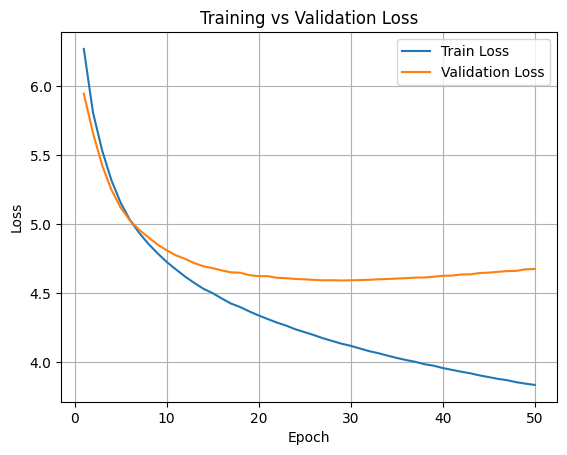

In [32]:
# 绘制 loss 曲线
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.savefig("loss.png", dpi=150, bbox_inches="tight")
plt.show()

# 步骤三：生成诗歌

In [33]:
def generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """给定几个词，根据这几个词接着生成一首完整的诗歌"""
    results = list(start_words)
    start_words_len = len(start_words)
    # 手动设置第一个词为<START>
    input = torch.Tensor([word2ix['<START>']]).view(1,1).long().to(device)      # tensor([8291.]) → tensor([[8291.]]) → tensor([[8291]])
    hidden = None

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):      # 最大生成长度
        output, hidden = model(input, hidden)

        if i < start_words_len:
            w = start_words[i]
            input = input.data.new([word2ix[w]]).view(1, 1)
        else:
            # 用预测的词作为新的输入，计算隐藏元和预测新的输出
            top_index = output.data[0].topk(1)[1][0]
            w = ix2word[top_index.item()] #TODO，书上是没有item()的
            results.append(w)
            input = input.data.new([top_index]).view(1, 1)
        if w == '<EOP>':
            break
    return results

In [34]:
def gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """生成藏头诗"""
    results = []
    start_words_len = len(start_words)  # 要生成的句子的数量
    input = torch.Tensor([word2ix['<START>']]).view(1, 1).long().to(device)
    hidden = None

    index = 0  # 用来指示已经生成了多少句藏头诗
    pre_word = '<START>'  # 上一个词

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):
        # 前向计算出概率最大的当前词
        output, hidden = model(input, hidden)
        top_index = output.data[0].topk(1)[1][0]
        w = ix2word[top_index.item()] # TODO:书上没有item()

        # 句首的字用藏头字代替
        if (pre_word in {'。', '！', '!', '？', '?', '<START>'}): #python3开始默认u
            #  如采遇到句号、感叹号等，把藏头的词作为下一个句的输入
            if index == start_words_len:
                # 如果生成的诗歌已经包含全部藏头的词，则结束
                break
            else:
                # 把藏头的词作为输入， 预测下一个词
                w = start_words[index]
                index += 1
                input = torch.Tensor([word2ix[w]]).view(1, 1).long().to(device)
        else:
            input = torch.Tensor([top_index]).view(1, 1).long().to(device)

        results.append(w)
        pre_word = w

    return results

基于你训练好的模型，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）。

In [35]:
# 生成诗歌相关配置
prefix_words = '江流天地外，山色有无中。'  # 不是诗歌的组成部分，用来控制生成诗歌的意境
max_gen_len = 200  # 生成诗歌最长长度

In [36]:
# 加载已保存的最终模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

PoetryModel(
  (embeddings): Embedding(8940, 256)
  (lstm): MultiLayerLSTM(
    (layers): ModuleList(
      (0-1): 2 x LSTMCell(
        (linear_x): Linear(in_features=256, out_features=1024, bias=True)
        (linear_h): Linear(in_features=256, out_features=1024, bias=True)
      )
    )
  )
  (linear1): Linear(in_features=256, out_features=8940, bias=True)
)

In [38]:
start_words = '深度学习'
result = gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

深意空山响，孤灯照夕阳。度关无限思，一望已成空。学道无为累，无名不可忘。习家生白发，新叶发新茎。


In [40]:
start_words = '大漠孤烟照高阁'
result = generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

大漠孤烟照高阁，一川水阔流沙涨。海水流流不可闻，舟中水阔无人闻。芦洲有客无处，山鸟不见人啼鸟。秋风吹雨不可闻，君不见天山水色新。千年万里无人见，一夜一夜愁不足。不知何处有残云，不是无人知我心。<EOP>


# 步骤四：大语言模型生成诗歌

使用Hugging Face的开源大模型，或通过openai API调用gpt系列模型。

自行设计prompt，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）；

In [3]:
# 此处我使用阿里云百炼 DashScope 兼容 OpenAI API 调用 deepseek-v4-flash 进行对比生成。
# API Key 不写入 notebook，放在与 lab2.ipynb 同目录的 mykey.txt 中。
from openai import OpenAI
from pathlib import Path


DASHSCOPE_BASE_URL = "https://dashscope.aliyuncs.com/compatible-mode/v1"
DASHSCOPE_MODEL = "deepseek-v4-flash"


def build_poetry_prompt(task, start_words):
    if task == 'acrostic':
        return (
            "请写一首七言绝句藏头诗，要求每句首字依次为以下四字："
            f"“{start_words}”，意境清雅，语言接近唐诗，只输出诗歌正文。"
        )
    if task == 'continue':
        return (
            f"请以“{start_words}”为开头续写一首古体诗，"
            "要求押韵自然、意象连贯，只输出诗歌正文。"
        )
    raise ValueError("task must be 'acrostic' or 'continue'")


def read_dashscope_api_key(key_file="mykey.txt"):
    candidates = [Path(key_file), Path("lab2") / key_file]
    for path in candidates:
        if path.exists():
            api_key = path.read_text(encoding="utf-8").strip()
            if api_key:
                return api_key
    raise RuntimeError(
        "未找到 API Key。请把阿里云百炼 API Key 写入与 lab2.ipynb 同目录的 mykey.txt，"
        "文件内容只保留 key 本身。"
    )


def get_dashscope_client():
    api_key = read_dashscope_api_key()
    return OpenAI(api_key=api_key, base_url=DASHSCOPE_BASE_URL)


def generate_with_dashscope(prompt, model=DASHSCOPE_MODEL, enable_thinking=False, stream=True):
    client = get_dashscope_client()
    messages = [{"role": "user", "content": prompt}]

    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        extra_body={"enable_thinking": enable_thinking},
        stream=stream,
        stream_options={"include_usage": True} if stream else None,
    )

    if not stream:
        return completion.choices[0].message.content

    reasoning_content = ""
    answer_content = ""
    is_answering = False

    for chunk in completion:
        if not chunk.choices:
            if getattr(chunk, "usage", None) is not None:
                print("\n" + "=" * 20 + "Token 消耗" + "=" * 20 + "\n")
                print(chunk.usage)
            continue

        delta = chunk.choices[0].delta

        if hasattr(delta, "reasoning_content") and delta.reasoning_content is not None:
            reasoning_content += delta.reasoning_content

        if hasattr(delta, "content") and delta.content:
            if not is_answering:
                is_answering = True
            print(delta.content, end="", flush=True)
            answer_content += delta.content

    print()
    return answer_content


acrostic_prompt = build_poetry_prompt('acrostic', '深度学习')
continue_prompt = build_poetry_prompt('continue', '大漠孤烟照高阁')

print("藏头诗：")
acrostic_result = generate_with_dashscope(acrostic_prompt)

print("\n续写诗：")
continue_result = generate_with_dashscope(continue_prompt)


藏头诗：
深林幽径隐烟霞，  
度水穿云访道家。  
学得长生清静法，  
习风拂面赏松花。
====================Token 消耗====================

CompletionUsage(completion_tokens=33, prompt_tokens=41, total_tokens=74, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cached_tokens=0))


续写诗：
大漠孤烟照高阁，长河落日映金城。  
玉门关外风沙暗，羌笛声中草木惊。  
千帐寒灯摇戍影，一川霜月冷边旌。  
何须更问封侯事，独倚危楼听雁鸣。
====================Token 消耗====================

CompletionUsage(completion_tokens=64, prompt_tokens=37, total_tokens=101, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cached_tokens=0))

